In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf

In [46]:
#plot 한글 적용
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [2]:
START_DATE = '2014-01-01'
END_DATE = '2018-12-31'

### 데이터 불러오기(2014~2018년도)

In [44]:
file_path = "../Data-collection/dailyStock"

In [22]:
target = "AMZN"
file_path = f"{file_path}/{target}.csv"
amzn_df = pd.read_csv(file_path, encoding="utf-8")

amzn_df['Date'] = pd.to_datetime(amzn_df['Date']) # 날짜로 변환
amzn_df = amzn_df.set_index('Date')               # Date를 인덱스로 설정
amzn_df = amzn_df.loc[START_DATE:END_DATE]  # 분석 기간

In [23]:
target = "^GSPC"
file_path = f"{file_path}/{target}.csv"
gold_df = pd.read_csv(file_path, encoding="utf-8")

gold_df['Date'] = pd.to_datetime(gold_df['Date']) # 날짜로 변환
gold_df = gold_df.set_index('Date')               # Date를 인덱스로 설정
gold_df = gold_df.loc[START_DATE:END_DATE]  # 분석 기간

In [45]:
target = "^IRX"
file_path = f"{file_path}/{target}.csv"
irx_df = pd.read_csv(file_path, encoding="utf-8")

irx_df['Date'] = pd.to_datetime(irx_df['Date']) # 날짜로 변환
irx_df = irx_df.set_index('Date')               # Date를 인덱스로 설정
irx_df = irx_df.loc[START_DATE:END_DATE]  # 분석 기간

In [35]:
#월단위 단순수익률
asset = amzn_df["adj_close"].rename("asset").resample("ME").last().pct_change().dropna()  
market = gold_df["adj_close"].rename("market").resample("ME").last().pct_change().dropna()

In [36]:
X = pd.concat([asset, market], axis=1)

covariance = X.cov().iloc[0,1]
benchmark_variance = X.market.var()
beta = covariance / benchmark_variance    #시장 움직임에 자산이 얼마나 민감하게 움직이는지를 나타내는 값 

In [39]:
y = X.pop("asset")
X = sm.add_constant(X)

capm_model = sm.OLS(y,X).fit()
print(capm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  asset   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     31.87
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           5.44e-07
Time:                        22:57:36   Log-Likelihood:                 75.306
No. Observations:                  59   AIC:                            -146.6
Df Residuals:                      57   BIC:                            -142.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0178      0.009      1.950      0.0

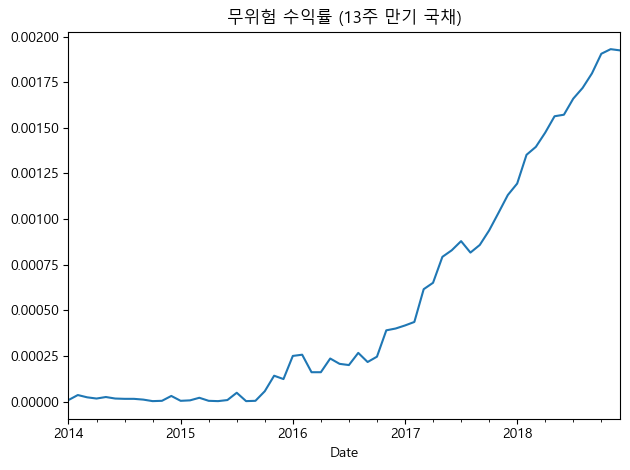

In [49]:
#3개월 설정 
N_DAYS = 90

#월 단위로 변경 및 수익률(%)를 소수로 변경
rf = irx_df.resample('ME').last().Close / 100

# 일간 수익률 복리 계산
rf = ( 1 / (1 - rf * N_DAYS / 360) )**(1 / N_DAYS)  

# 월간 수익률로 변환
rf = (rf ** 30) - 1 

rf.plot(title='무위험 수익률 (13주 만기 국채)')

plt.tight_layout()
plt.show()